# What this notebook will do
load the FEMA county-level NRI table

inspect columns

find likely wildfire-related fields

build a clean county table

create a main target:

wildfire_eal
and also log_wildfire_eal

# Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

# **Cell 2 — Upload / locate the FEMA county CSV**

In [2]:
# Replace with your uploaded FEMA county CSV filename
CSV_PATH = "/content/NRI_Table_Counties.csv"

df = pd.read_csv(CSV_PATH, low_memory=False)

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Shape: (3232, 465)

First 5 rows:


,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,POPULATION,BUILDVALUE,AGRIVALUE,AREA,RISK_VALUE,RISK_SCORE,RISK_RATNG,RISK_SPCTL,EAL_SCORE,EAL_RATNG,EAL_SPCTL,EAL_VALT,EAL_VALB,EAL_VALP,EAL_VALPE,EAL_VALA,ALR_VALB,ALR_VALP,ALR_VALA,ALR_NPCTL,ALR_VRA_NPCTL,SOVI_SCORE,SOVI_RATNG,SOVI_SPCTL,RESL_SCORE,RESL_RATNG,RESL_SPCTL,RESL_VALUE,CRF_VALUE,AVLN_EVNTS,AVLN_AFREQ,AVLN_EXP_AREA,AVLN_EXPB,AVLN_EXPP,AVLN_EXPPE,AVLN_EXPT,AVLN_HLRB,AVLN_HLRP,AVLN_HLRR,AVLN_EALB,AVLN_EALP,AVLN_EALPE,AVLN_EALT,AVLN_EALS,AVLN_EALR,AVLN_ALRB,AVLN_ALRP,AVLN_ALR_NPCTL,AVLN_RISKV,AVLN_RISKS,AVLN_RISKR,CFLD_EVNTS,CFLD_AFREQ,CFLD_EXP_AREA,CFLD_EXPB,CFLD_EXPP,CFLD_EXPPE,CFLD_EXPT,CFLD_HLRB,CFLD_HLRP,CFLD_HLRR,CFLD_EALB,CFLD_EALP,CFLD_EALPE,CFLD_EALT,CFLD_EALS,CFLD_EALR,CFLD_ALRB,CFLD_ALRP,CFLD_ALR_NPCTL,CFLD_RISKV,CFLD_RISKS,CFLD_RISKR,CWAV_EVNTS,CWAV_AFREQ,CWAV_EXP_AREA,CWAV_EXPB,CWAV_EXPP,CWAV_EXPPE,CWAV_EXPA,CWAV_EXPT,CWAV_HLRB,CWAV_HLRP,CWAV_HLRA,CWAV_HLRR,CWAV_EALB,CWAV_EALP,CWAV_EALPE,CWAV_EALA,CWAV_EALT,CWAV_EALS,...,TRND_RISKV,TRND_RISKS,TRND_RISKR,TSUN_EVNTS,TSUN_AFREQ,TSUN_EXP_AREA,TSUN_EXPB,TSUN_EXPP,TSUN_EXPPE,TSUN_EXPT,TSUN_HLRB,TSUN_HLRP,TSUN_HLRR,TSUN_EALB,TSUN_EALP,TSUN_EALPE,TSUN_EALT,TSUN_EALS,TSUN_EALR,TSUN_ALRB,TSUN_ALRP,TSUN_ALR_NPCTL,TSUN_RISKV,TSUN_RISKS,TSUN_RISKR,VLCN_EVNTS,VLCN_AFREQ,VLCN_EXP_AREA,VLCN_EXPB,VLCN_EXPP,VLCN_EXPPE,VLCN_EXPT,VLCN_HLRB,VLCN_HLRP,VLCN_HLRR,VLCN_EALB,VLCN_EALP,VLCN_EALPE,VLCN_EALT,VLCN_EALS,VLCN_EALR,VLCN_ALRB,VLCN_ALRP,VLCN_ALR_NPCTL,VLCN_RISKV,VLCN_RISKS,VLCN_RISKR,WFIR_EVNTS,WFIR_AFREQ,WFIR_EXP_AREA,WFIR_EXPB,WFIR_EXPP,WFIR_EXPPE,WFIR_EXPA,WFIR_EXPT,WFIR_HLRB,WFIR_HLRP,WFIR_HLRA,WFIR_HLRR,WFIR_EALB,WFIR_EALP,WFIR_EALPE,WFIR_EALA,WFIR_EALT,WFIR_EALS,WFIR_EALR,WFIR_ALRB,WFIR_ALRP,WFIR_ALRA,WFIR_ALR_NPCTL,WFIR_RISKV,WFIR_RISKS,WFIR_RISKR,WNTW_EVNTS,WNTW_AFREQ,WNTW_EXP_AREA,WNTW_EXPB,WNTW_EXPP,WNTW_EXPPE,WNTW_EXPA,WNTW_EXPT,WNTW_HLRB,WNTW_HLRP,WNTW_HLRA,WNTW_HLRR,WNTW_EALB,WNTW_EALP,WNTW_EALPE,WNTW_EALA,WNTW_EALT,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
0,1,C01001,Alabama,AL,1,Autauga,County,1,1001,58764,1.024141e+10,27630646.0,610.470508,2.051090e+07,57.569975,Relatively Low,57.569975,59.870050,Relatively Low,56.716418,1.975657e+07,1.385350e+07,0.412821,5.655652e+06,2.474187e+05,0.001518,0.000007,0.010052,49.721535,45.515267,38.040712,Relatively Low,9.701493,55.120865,Relatively Moderate,76.119403,2.494860,1.038181,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,7.000000,0.368421,610.470508,1.024141e+10,58764.0,8.050668e+11,27630646.0,8.153358e+11,8.092943e-07,1.205327e-07,0.001287,Relatively Low,3053.588720,0.026571,3.640163e+05,13096.648973,3.801666e+05,31.219059,...,3.112728e+06,74.109415,Relatively Moderate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,NaN,NaN,NaN,NaN,Not Applicable,NaN,0.000569,23.109638,1.367163e+09,10559.815261,1.446695e+11,4.004713e+06,1.460406e+11,0.1,0.000117,0.007141,Very Low,3.002976e+04,0.000454,6216.075404,16.406169,3.626224e+04,47.105598,Very Low,0.000003,7.721192e-09,5.937671e-07,41.348601,3.764677e+04,45.737913,Very Low,26.00000,1.368421,610.470508,1.024141e+10,58764.0,8.050668e+11,27630646.0,8.153358e+11,1.606919e-07,3.977501e-09,1.040342e-06,Very Low,2252.026376,0.000320,4381.894510,39.336299,6673.257184,13.095975,Very Low,2.198943e-07,5.442896e-09,1.423647e-06,27.739938,6928.050098,9.038829,Very Low,December 2025
1,2,C01003,Alabama,AL,1,Baldwin,County,3,1003,231365,5.160230e+10,155012958.0,2047.738775,2.532687e+08,96.723919,Relatively High,96.723919,96.627475,Relatively High,97.014925,2.373912e+08,2.084471e+08,1.932259,2.6471

# **Cell 3 — Inspect all columns**

In [3]:
print("Number of columns:", len(df.columns))
print("\nAll columns:")
for i, col in enumerate(df.columns):
    print(f"{i:03d}: {col}")

Number of columns: 465

All columns:
000: OID_
001: NRI_ID
002: STATE
003: STATEABBRV
004: STATEFIPS
005: COUNTY
006: COUNTYTYPE
007: COUNTYFIPS
008: STCOFIPS
009: POPULATION
010: BUILDVALUE
011: AGRIVALUE
012: AREA
013: RISK_VALUE
014: RISK_SCORE
015: RISK_RATNG
016: RISK_SPCTL
017: EAL_SCORE
018: EAL_RATNG
019: EAL_SPCTL
020: EAL_VALT
021: EAL_VALB
022: EAL_VALP
023: EAL_VALPE
024: EAL_VALA
025: ALR_VALB
026: ALR_VALP
027: ALR_VALA
028: ALR_NPCTL
029: ALR_VRA_NPCTL
030: SOVI_SCORE
031: SOVI_RATNG
032: SOVI_SPCTL
033: RESL_SCORE
034: RESL_RATNG
035: RESL_SPCTL
036: RESL_VALUE
037: CRF_VALUE
038: AVLN_EVNTS
039: AVLN_AFREQ
040: AVLN_EXP_AREA
041: AVLN_EXPB
042: AVLN_EXPP
043: AVLN_EXPPE
044: AVLN_EXPT
045: AVLN_HLRB
046: AVLN_HLRP
047: AVLN_HLRR
048: AVLN_EALB
049: AVLN_EALP
050: AVLN_EALPE
051: AVLN_EALT
052: AVLN_EALS
053: AVLN_EALR
054: AVLN_ALRB
055: AVLN_ALRP
056: AVLN_ALR_NPCTL
057: AVLN_RISKV
058: AVLN_RISKS
059: AVLN_RISKR
060: CFLD_EVNTS
061: CFLD_AFREQ
062: CFLD_EXP_AREA
063:

# **Cell 4 — Find likely wildfire columns automatically**
This cell searches for columns that may correspond to wildfire by looking for names like:

wildfire

wfir

fire

In [4]:
wildfire_candidates = [
    c for c in df.columns
    if re.search(r"(wildfire|wfir|fire)", c, flags=re.IGNORECASE)
]

print("Likely wildfire-related columns:")
for c in wildfire_candidates:
    print(c)

Likely wildfire-related columns:
WFIR_EVNTS
WFIR_AFREQ
WFIR_EXP_AREA
WFIR_EXPB
WFIR_EXPP
WFIR_EXPPE
WFIR_EXPA
WFIR_EXPT
WFIR_HLRB
WFIR_HLRP
WFIR_HLRA
WFIR_HLRR
WFIR_EALB
WFIR_EALP
WFIR_EALPE
WFIR_EALA
WFIR_EALT
WFIR_EALS
WFIR_EALR
WFIR_ALRB
WFIR_ALRP
WFIR_ALRA
WFIR_ALR_NPCTL
WFIR_RISKV
WFIR_RISKS
WFIR_RISKR


# **Cell 5 — Find likely county ID columns**

In [5]:
id_candidates = [
    c for c in df.columns
    if re.search(r"(fips|geoid|county|state|name)", c, flags=re.IGNORECASE)
]

print("Likely ID / geography columns:")
for c in id_candidates:
    print(c)

Likely ID / geography columns:
STATE
STATEABBRV
STATEFIPS
COUNTY
COUNTYTYPE
COUNTYFIPS
STCOFIPS


# **Cell 6 — Helper to score likely column matches**
This helps you identify the best column names even if FEMA used abbreviations.

In [6]:
def rank_columns(columns, include_patterns, exclude_patterns=None):
    exclude_patterns = exclude_patterns or []
    ranked = []
    for c in columns:
        name = c.lower()
        include_score = sum(bool(re.search(p, name)) for p in include_patterns)
        exclude_score = sum(bool(re.search(p, name)) for p in exclude_patterns)
        ranked.append((c, include_score, exclude_score))
    ranked = sorted(ranked, key=lambda x: (x[1], -x[2], x[0]), reverse=True)
    return ranked

print("Top likely wildfire EAL columns:")
for item in rank_columns(
    df.columns,
    include_patterns=[r"(wildfire|wfir|fire)", r"(eal|expected)", r"(loss|dollar|building|population|agriculture)?"],
    exclude_patterns=[r"all hazards", r"rating", r"score"]
)[:30]:
    print(item)

print("\nTop likely wildfire score columns:")
for item in rank_columns(
    df.columns,
    include_patterns=[r"(wildfire|wfir|fire)", r"score"],
    exclude_patterns=[r"rating"]
)[:20]:
    print(item)

print("\nTop likely wildfire rating columns:")
for item in rank_columns(
    df.columns,
    include_patterns=[r"(wildfire|wfir|fire)", r"rating"],
    exclude_patterns=[r"score"]
)[:20]:
    print(item)

Top likely wildfire EAL columns:
('WFIR_EALT', 3, 0)
('WFIR_EALS', 3, 0)
('WFIR_EALR', 3, 0)
('WFIR_EALPE', 3, 0)
('WFIR_EALP', 3, 0)
('WFIR_EALB', 3, 0)
('WFIR_EALA', 3, 0)
('WNTW_EALT', 2, 0)
('WNTW_EALS', 2, 0)
('WNTW_EALR', 2, 0)
('WNTW_EALPE', 2, 0)
('WNTW_EALP', 2, 0)
('WNTW_EALB', 2, 0)
('WNTW_EALA', 2, 0)
('WFIR_RISKV', 2, 0)
('WFIR_RISKS', 2, 0)
('WFIR_RISKR', 2, 0)
('WFIR_HLRR', 2, 0)
('WFIR_HLRP', 2, 0)
('WFIR_HLRB', 2, 0)
('WFIR_HLRA', 2, 0)
('WFIR_EXP_AREA', 2, 0)
('WFIR_EXPT', 2, 0)
('WFIR_EXPPE', 2, 0)
('WFIR_EXPP', 2, 0)
('WFIR_EXPB', 2, 0)
('WFIR_EXPA', 2, 0)
('WFIR_EVNTS', 2, 0)
('WFIR_ALR_NPCTL', 2, 0)
('WFIR_ALRP', 2, 0)

Top likely wildfire score columns:
('WFIR_RISKV', 1, 0)
('WFIR_RISKS', 1, 0)
('WFIR_RISKR', 1, 0)
('WFIR_HLRR', 1, 0)
('WFIR_HLRP', 1, 0)
('WFIR_HLRB', 1, 0)
('WFIR_HLRA', 1, 0)
('WFIR_EXP_AREA', 1, 0)
('WFIR_EXPT', 1, 0)
('WFIR_EXPPE', 1, 0)
('WFIR_EXPP', 1, 0)
('WFIR_EXPB', 1, 0)
('WFIR_EXPA', 1, 0)
('WFIR_EVNTS', 1, 0)
('WFIR_EALT', 1, 0)
('WFIR

# **Cell 7 — Manually set the correct columns**

In [9]:
# =========================
# SELECTED COLUMN NAMES
# =========================

COL_STATE       = "STATE"
COL_COUNTY      = "COUNTY"
COL_COUNTY_FIPS = "STCOFIPS"

# Main wildfire target
COL_WF_EAL      = "WFIR_EALT"

# Optional wildfire context columns
COL_WF_SCORE    = "WFIR_RISKS"
COL_WF_RATING   = "WFIR_RISKR"

COL_SOVI_SCORE  = None
COL_RESL_SCORE  = None

# **Cell 8 — Validate selected columns**

In [10]:
selected = [
    COL_STATE,
    COL_COUNTY,
    COL_COUNTY_FIPS,
    COL_WF_EAL,
    COL_WF_SCORE,
    COL_WF_RATING
]

optional_selected = [COL_SOVI_SCORE, COL_RESL_SCORE]
selected = [c for c in selected if c is not None]
optional_selected = [c for c in optional_selected if c is not None]

print("Selected columns:", selected)

missing = [c for c in selected + optional_selected if c not in df.columns]
if missing:
    raise ValueError(f"These columns were not found in the CSV: {missing}")

print("All selected columns were found.")

Selected columns: ['STATE', 'COUNTY', 'STCOFIPS', 'WFIR_EALT', 'WFIR_RISKS', 'WFIR_RISKR']
All selected columns were found.


# **Cell 9 — Build the clean wildfire county table**

In [11]:
extra_wildfire_cols = [
    "WFIR_EVNTS",
    "WFIR_AFREQ",
    "WFIR_EALB",
    "WFIR_EALP",
    "WFIR_EALA",
    "WFIR_EALS",
    "WFIR_EALR",
    "WFIR_RISKV"
]

keep_cols = [
    COL_STATE, COL_COUNTY, COL_COUNTY_FIPS,
    COL_WF_EAL, COL_WF_SCORE, COL_WF_RATING
] + extra_wildfire_cols

risk_df = df[keep_cols].copy()

rename_map = {
    COL_STATE: "state",
    COL_COUNTY: "county",
    COL_COUNTY_FIPS: "county_fips",
    COL_WF_EAL: "wildfire_eal",
    COL_WF_SCORE: "wildfire_risk_score",
    COL_WF_RATING: "wildfire_risk_rating",
    "WFIR_EVNTS": "wildfire_events",
    "WFIR_AFREQ": "wildfire_annual_frequency",
    "WFIR_EALB": "wildfire_eal_buildings",
    "WFIR_EALP": "wildfire_eal_population",
    "WFIR_EALA": "wildfire_eal_agriculture",
    "WFIR_EALS": "wildfire_eal_score_like",
    "WFIR_EALR": "wildfire_eal_rating_like",
    "WFIR_RISKV": "wildfire_risk_value"
}

risk_df = risk_df.rename(columns=rename_map)

risk_df["county_fips"] = (
    risk_df["county_fips"]
    .astype(str)
    .str.extract(r"(\d+)")[0]
    .str.zfill(5)
)

numeric_cols = [c for c in risk_df.columns if c not in ["state", "county", "county_fips", "wildfire_risk_rating", "wildfire_eal_rating_like"]]
for col in numeric_cols:
    risk_df[col] = pd.to_numeric(risk_df[col], errors="coerce")

print("Clean risk table shape:", risk_df.shape)
display(risk_df.head())

Clean risk table shape: (3232, 14)


,state,county,county_fips,wildfire_eal,wildfire_risk_score,wildfire_risk_rating,wildfire_events,wildfire_annual_frequency,wildfire_eal_buildings,wildfire_eal_population,wildfire_eal_agriculture,wildfire_eal_score_like,wildfire_eal_rating_like,wildfire_risk_value
0,Alabama,Autauga,01001,3.626224e+04,45.737913,Very Low,NaN,0.000569,3.002976e+04,0.000454,16.406169,47.105598,Very Low,3.764677e+04
1,Alabama,Baldwin,01003,1.500314e+06,90.776081,Relatively Moderate,NaN,0.003136,1.282742e+06,0.015847,470.262851,91.125954,Relatively Moderate,1.600660e+06
2,Alabama,Barbour,01005,2.590932e+04,48.854962,Very Low,NaN,0.000688,2.161196e+04,0.000303,150.438881,41.666667,Very Low,4.644979e+04
3,Alabama,Bibb,01007,3.260612e+04,48.664122,Very Low,NaN,0.000999,2.579498e+04,0.000497,8.942955,45.451654,Very Low,4.594325e+04
4,Alabama,Blount,01009,9.336726e+04,65.044529,Relatively Low,NaN,0.001551,7.351167e+04,0.001407,581.805384,62.468193,Relatively Low,1.258597e+05


# **Cell 10 — Check missingness and duplicates**

In [12]:
print("Missing values by column:")
print(risk_df.isna().sum())

print("\nDuplicate county_fips rows:", risk_df["county_fips"].duplicated().sum())

dups = risk_df[risk_df["county_fips"].duplicated(keep=False)].sort_values("county_fips")
if len(dups) > 0:
    print("\nDuplicate county_fips rows:")
    display(dups.head(20))

Missing values by column:
state                           0
county                          0
county_fips                     0
wildfire_eal                   88
wildfire_risk_score            88
wildfire_risk_rating            0
wildfire_events              3232
wildfire_annual_frequency      88
wildfire_eal_buildings         88
wildfire_eal_population        88
wildfire_eal_agriculture       88
wildfire_eal_score_like        88
wildfire_eal_rating_like        0
wildfire_risk_value            88
dtype: int64

Duplicate county_fips rows: 0


# **Cell 11 — Basic target exploration**

In [13]:
print("Initial shape:", risk_df.shape)

# Drop fully empty column
if "wildfire_events" in risk_df.columns and risk_df["wildfire_events"].isna().all():
    risk_df = risk_df.drop(columns=["wildfire_events"])
    print("Dropped fully empty column: wildfire_events")

# Keep rows where the main target exists
risk_df = risk_df[risk_df["wildfire_eal"].notna()].copy()

print("Shape after dropping rows with missing wildfire_eal:", risk_df.shape)

print("\nMissing values after cleaning:")
print(risk_df.isna().sum())

print("\nZero wildfire_eal:", (risk_df["wildfire_eal"] == 0).sum())
print("Positive wildfire_eal:", (risk_df["wildfire_eal"] > 0).sum())

print("\nSummary of wildfire_eal:")
print(risk_df["wildfire_eal"].describe())

Initial shape: (3232, 14)
Dropped fully empty column: wildfire_events
Shape after dropping rows with missing wildfire_eal: (3144, 13)

Missing values after cleaning:
state                        0
county                       0
county_fips                  0
wildfire_eal                 0
wildfire_risk_score          0
wildfire_risk_rating         0
wildfire_annual_frequency    0
wildfire_eal_buildings       0
wildfire_eal_population      0
wildfire_eal_agriculture     0
wildfire_eal_score_like      0
wildfire_eal_rating_like     0
wildfire_risk_value          0
dtype: int64

Zero wildfire_eal: 1
Positive wildfire_eal: 3143

Summary of wildfire_eal:
count    3.144000e+03
mean     1.238704e+06
std      1.129833e+07
min      0.000000e+00
25%      9.942501e+03
50%      4.211249e+04
75%      2.328656e+05
max      4.301560e+08
Name: wildfire_eal, dtype: float64


# **Cell 12 — Create log target**

In [14]:
risk_df["log_wildfire_eal"] = np.log1p(risk_df["wildfire_eal"])

display(
    risk_df[
        ["state", "county", "county_fips", "wildfire_eal", "log_wildfire_eal",
         "wildfire_risk_score", "wildfire_risk_rating"]
    ].head(10)
)

,state,county,county_fips,wildfire_eal,log_wildfire_eal,wildfire_risk_score,wildfire_risk_rating
0,Alabama,Autauga,01001,3.626224e+04,10.498560,45.737913,Very Low
1,Alabama,Baldwin,01003,1.500314e+06,14.221186,90.776081,Relatively Moderate
2,Alabama,Barbour,01005,2.590932e+04,10.162397,48.854962,Very Low
3,Alabama,Bibb,01007,3.260612e+04,10.392286,48.664122,Very Low
4,Alabama,Blount,01009,9.336726e+04,11.444307,65.044529,Relatively Low
5,Alabama,Bullock,01011,2.229438e+04,10.012135,46.087786,Very Low
6,Alabama,Butler,01013,9.859778e+03,9.196320,31.075064,Very Low
7,Alabama,Calhoun,01015,3.404425e+05,12.738005,81.520356,Relatively Low
8,Alabama,Chambers,01017,3.777103e+04,10.539324,51.653944,Very Low
9,Alabama,Cherokee,01019,1.069436e+05,11.580067,68.225191,Relatively Low


# **Cell 13 — Plot distributions**

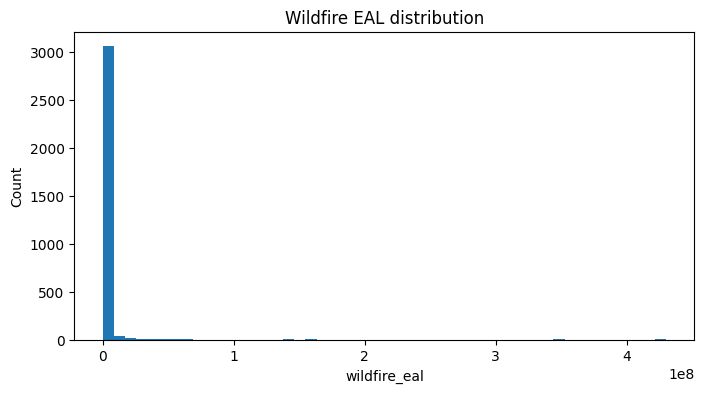

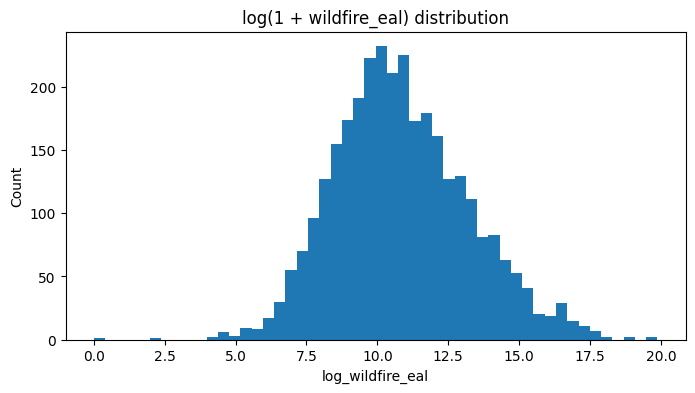

In [15]:
plt.figure(figsize=(8, 4))
plt.hist(risk_df["wildfire_eal"], bins=50)
plt.title("Wildfire EAL distribution")
plt.xlabel("wildfire_eal")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(risk_df["log_wildfire_eal"], bins=50)
plt.title("log(1 + wildfire_eal) distribution")
plt.xlabel("log_wildfire_eal")
plt.ylabel("Count")
plt.show()

# **Cell 14 — Top counties by wildfire EAL**

In [16]:
top20 = risk_df.sort_values("wildfire_eal", ascending=False).head(20)

display(
    top20[
        ["state", "county", "county_fips", "wildfire_eal",
         "wildfire_risk_score", "wildfire_risk_rating",
         "wildfire_eal_buildings", "wildfire_eal_population", "wildfire_eal_agriculture"]
    ]
)

,state,county,county_fips,wildfire_eal,wildfire_risk_score,wildfire_risk_rating,wildfire_eal_buildings,wildfire_eal_population,wildfire_eal_agriculture
223,California,San Diego,06073,4.301560e+08,100.000000,Very High,4.152653e+08,1.081512,73993.648056
219,California,Riverside,06065,3.466428e+08,99.968193,Very High,3.275603e+08,1.390833,28066.335510
205,California,Los Angeles,06037,1.551918e+08,99.936387,Very High,1.485559e+08,0.484204,2331.132410
222,California,San Bernardino,06071,1.457376e+08,99.904580,Very High,1.390686e+08,0.486193,8238.859310
2796,Utah,Washington,49053,6.756125e+07,99.840967,Relatively High,6.419149e+07,0.245920,653.981007
1743,Nevada,Elko,32007,6.163663e+07,99.872774,Relatively High,5.881300e+07,0.205569,7336.187310
216,California,Orange,06059,5.758562e+07,99.809160,Relatively High,5.481209e+07,0.202186,3584.690356
195,California,El Dorado,06017,5.520508e+07,99.713740,Relatively High,5.255259e+07,0.193565,641.013626
242,California,Ventura,06111,5.010780e+07,99.777354,Relatively High,4.797043e+07,0.152663,45898.115709
275,Colorado,Jefferson,08059,4.873285e+07,99.522901,Relatively High,4.672040e+07,0.146887,98.183452


# **Cell 15 — Save clean output**

In [17]:
OUT_PATH = "/content/nri_wildfire_county_target.csv"
risk_df.to_csv(OUT_PATH, index=False)
print("Saved:", OUT_PATH)

Saved: /content/nri_wildfire_county_target.csv


# **Cell 16 — Save a lightweight modeling version**

In [18]:
model_df = risk_df.copy()

# Drop rows with no target
model_df = model_df[model_df["wildfire_eal"].notna()].copy()

# Keep a minimal set for now
base_cols = [
    "state",
    "county",
    "county_fips",
    "wildfire_eal",
    "log_wildfire_eal",
    "wildfire_risk_score",
    "wildfire_risk_rating"
]

extra_cols = [c for c in ["social_vulnerability_score", "community_resilience_score"] if c in model_df.columns]
model_df = model_df[base_cols + extra_cols]

MODEL_PATH = "/content/nri_wildfire_county_target_minimal.csv"
model_df.to_csv(MODEL_PATH, index=False)

print("Saved modeling file:", MODEL_PATH)
print("Final modeling shape:", model_df.shape)
display(model_df.head())

Saved modeling file: /content/nri_wildfire_county_target_minimal.csv
Final modeling shape: (3144, 7)


,state,county,county_fips,wildfire_eal,log_wildfire_eal,wildfire_risk_score,wildfire_risk_rating
0,Alabama,Autauga,01001,3.626224e+04,10.498560,45.737913,Very Low
1,Alabama,Baldwin,01003,1.500314e+06,14.221186,90.776081,Relatively Moderate
2,Alabama,Barbour,01005,2.590932e+04,10.162397,48.854962,Very Low
3,Alabama,Bibb,01007,3.260612e+04,10.392286,48.664122,Very Low
4,Alabama,Blount,01009,9.336726e+04,11.444307,65.044529,Relatively Low
